In [31]:
import sys
print(sys.executable)

/Applications/Xcode.app/Contents/Developer/usr/bin/python3


In [32]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install numpy matplotlib qutip

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

print(np.__version__)
print(qt.__version__)

2.0.2
5.0.4


In [34]:
# Constants

gamma_e = 1.760859e11  # gyromagnetic ratio of the electron, rad/s/T
B0 = 47e-6 # geomagnetic field strength, T

# a_hf_time = 1 microsecond means hyperfine interaction time = 1/a
a_hf_time = 1.0e-6 # seconds
A0 = 1 / a_hf_time # rad/s

# Anisotropic hyperfine tensor
# Borrowed from Bandyopadhyay 

# A_tensor_default = np.diag([A0, A0, 2*A0]) # rad/s

# Single-spin operators

# identity matrix makes this similar to identity property
I2 = qt.qeye(2)

# pauli matrices
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()   

# Stern-gerlach experiment measured that the spin component along any axis is 
# quantized in units of hbar/2.
Sx = 0.5 * sx
Sy = 0.5 * sy
Sz = 0.5 * sz

In [35]:
# 8D Hilbert Space
# Must have 3 parts because of 8D space
# Sx, Sy, and Sz represent spin components 

# Electron 1 spin operators
S1x = qt.tensor(Sx, I2, I2)
S1y = qt.tensor(Sy, I2, I2)
S1z = qt.tensor(Sz, I2, I2)

# Electron 2 spin operators
S2x = qt.tensor(I2, Sx, I2)
S2y = qt.tensor(I2, Sy, I2)
S2z = qt.tensor(I2, Sz, I2)

# Nuclear spin operators
Ix = qt.tensor(I2, I2, Sx)
Iy = qt.tensor(I2, I2, Sy)
Iz = qt.tensor(I2, I2, Sz)

# Full identity operators 
I8 = qt.tensor(I2, I2, I2)

# Pauli operators on electrons for later Lindblad decoherence
X1 = qt.tensor(sx, I2, I2)
Y1 = qt.tensor(sy, I2, I2)
Z1 = qt.tensor(sz, I2, I2)  

X2 = qt.tensor(I2, sx, I2)
Y2 = qt.tensor(I2, sy, I2)
Z2 = qt.tensor(I2, sz, I2)

In [36]:
# Basis states

# Makes a 2D vector with 1 in the position index and 0 everywhere else
up = qt.basis(2,0)
down = qt.basis(2,1)

# Electron singlet state
singlet_e = (qt.tensor(up, down) - qt.tensor(down, up)).unit()

#singlet projector for two electrons only
P_S_e = singlet_e * singlet_e.dag()

# singlet projector for the full system (electrons + nucleus)
P_S = qt.tensor(P_S_e, I2)

P_T = I8 - P_S

In [37]:
# Initial density matrix

# Electron singlet density matrix
rho_e = P_S_e

# unpolarized nuclear spin state - 50% up or down
rho_n = 0.5 * I2

# Full initial density matrix (electron singlet + mixed nucleus)
rho0 = qt.tensor(rho_e, rho_n)

# measures the trace of the matrix, which should be 1 for a valid density matrix
print("Initial Trace:", rho0.tr())
print("Initial singlet probability:", qt.expect(P_S, rho0))
print("Projector check ||P_S + P_T - I||:", (P_S + P_T - I8).norm())



Initial Trace: 0.9999999999999998
Initial singlet probability: 0.9999999999999998
Projector check ||P_S + P_T - I||: 0.0


In [38]:
def bandyopadhyay_hyperfine_tensor(a_bar_time=1.0e-6):
    """
    Returns axial anisotropic hyperfine tensor in rad/s.

    a_bar_time:
        Hyperfine timescale in seconds.
    Returns:
        A_tensor = diag([a, a, 2a])
    """
    A_norm = 2.0 * np.pi / a_bar_time
    a_component = A_norm / np.sqrt(6.0)

    A_tensor = np.diag([
        a_component,
        a_component,
        2.0 * a_component
    ])

    return A_tensor


A_tensor_default = bandyopadhyay_hyperfine_tensor(a_bar_time=1.0e-6)

print("\nDefault hyperfine tensor, rad/s:")
print(A_tensor_default)

A_norm_check = np.sqrt(np.sum(A_tensor_default**2))
print("HF norm A, rad/s:", A_norm_check)
print("HF period 2π/A, s:", 2.0 * np.pi / A_norm_check)


Default hyperfine tensor, rad/s:
[[2565099.66032373       0.               0.        ]
 [      0.         2565099.66032373       0.        ]
 [      0.               0.         5130199.32064746]]
HF norm A, rad/s: 6283185.307179588
HF period 2π/A, s: 9.999999999999997e-07


In [39]:
def magnetic_field_vector(theta_deg, B_strength=B0, phi_deg=0):
    """
    B = B0 (sin(theta) cos(phi), sin(theta) sin(phi), cos(theta))

    theta_deg: inclination angle from molecular z-axis
    phi_deg: azimuthal angle around z-axis

    """

    # converts degrees to radians for the trig
    theta = np.deg2rad(theta_deg)
    phi = np.deg2rad(phi_deg)

    Bx = B_strength * np.sin(theta) * np.cos(phi)
    By = B_strength * np.sin(theta) * np.sin(phi)
    Bz = B_strength * np.cos(theta)

    return np.array([Bx, By, Bz], dtype = float)

In [40]:
def build_zeeman_hamiltonian(theta_deg, B_strength=B0, phi_deg=0.0):
    """
    Zeeman Hamiltonian:
    H_Z = gamma_e B · (S1 + S2)

    Units: rad/s
    """
    Bx, By, Bz = magnetic_field_vector(
        theta_deg=theta_deg,
        B_strength=B_strength,
        phi_deg=phi_deg
    )

    H_Z = gamma_e * (
        Bx * (S1x + S2x)
        + By * (S1y + S2y)
        + Bz * (S1z + S2z)
    )

    return H_Z


def build_hyperfine_hamiltonian(A_tensor):
    """
    Hyperfine Hamiltonian:
    H_HF = sum_ij S1_i A_ij I_j

    Electron 1 couples to one effective nuclear spin.
    Electron 2 is free from nuclear coupling.
    """
    S1_ops = [S1x, S1y, S1z]
    I_ops = [Ix, Iy, Iz]

    H_HF = 0 * I8

    for i in range(3):
        for j in range(3):
            H_HF += A_tensor[i, j] * S1_ops[i] * I_ops[j]

    return H_HF


def build_total_hamiltonian(
    theta_deg,
    B_strength=B0,
    phi_deg=0.0,
    A_tensor=None,
    include_zeeman=True,
    include_hyperfine=True
):
    """
    Total radical-pair Hamiltonian:
    H = H_Z + H_HF
    """
    if A_tensor is None:
        A_tensor = A_tensor_default

    H = 0 * I8

    if include_zeeman:
        H += build_zeeman_hamiltonian(
            theta_deg=theta_deg,
            B_strength=B_strength,
            phi_deg=phi_deg
        )

    if include_hyperfine:
        H += build_hyperfine_hamiltonian(A_tensor)

    return H

In [41]:
def evolve_singlet_probability(H, rho_initial, tlist):
    """
    Evolves rho under Hamiltonian H and returns singlet probability over time.

    This is evolution only, no recombination or decoherence.
    """
    #mesolve(Hamiltonian, initial state, time list, collapse operators, expectation operators)
    #collapse operators not there = no decoherence
    result = qt.mesolve(H, rho_initial, tlist, c_ops=[], e_ops=[P_S])

    return np.array(result.expect[0])

In [42]:
def isotropic_decoherence_c_ops(Gamma_iso=0.0):
    """
    Isotropic Lindblad noise on both electrons.

    Uses six Pauli noise operators:
    σx, σy, σz on electron 1
    σx, σy, σz on electron 2

    In QuTiP, collapse operators are sqrt(rate) * operator.
    """
    if Gamma_iso is None or Gamma_iso <= 0:
        return []

    noise_ops = [X1, Y1, Z1, X2, Y2, Z2]
    return [np.sqrt(Gamma_iso) * op for op in noise_ops]

In [43]:
def integrate_trapezoid(y, x):
    """
    Works with both newer and older NumPy versions.
    """
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return np.trapz(y, x)

In [44]:
def simulate_haberkorn_for_theta(
    theta_deg,
    kS=2.0e5,
    kT=None,
    a_bar_time=1.0e-6,
    B_strength=B0,
    phi_deg=0.0,
    Gamma_iso=0.0,
    t_max=None,
    n_steps=4000,
    n_lifetimes=12
):
    """
    Computes singlet product yield ΦS for one theta.

    Returns:
        dictionary containing time traces, yields, and checks
    """
    if kT is None:
        kT = kS

    if kS <= 0 or kT <= 0:
        raise ValueError("kS and kT must be positive.")

    if t_max is None:
        slowest_rate = min(kS, kT)
        t_max = n_lifetimes / slowest_rate

    tlist = np.linspace(0.0, t_max, n_steps)

    A_tensor = bandyopadhyay_hyperfine_tensor(a_bar_time=a_bar_time)

    H = build_total_hamiltonian(
        theta_deg=theta_deg,
        B_strength=B_strength,
        phi_deg=phi_deg,
        A_tensor=A_tensor,
        include_zeeman=True,
        include_hyperfine=True
    )

    # Haberkorn recombination operator
    K = kS * P_S + kT * P_T

    # Non-Hermitian effective Hamiltonian
    H_eff = H - 0.5j * K

    # Optional environmental decoherence
    c_ops = isotropic_decoherence_c_ops(Gamma_iso)

    result = qt.mesolve(
        H_eff,
        rho0,
        tlist,
        c_ops=c_ops,
        e_ops=[P_S, P_T, I8],
        options={
            "nsteps": 20000,
            "atol": 1e-10,
            "rtol": 1e-8,
            "normalize_output": False,
            "store_states": False
        }
    )

    P_S_t = np.real(np.array(result.expect[0]))
    P_T_t = np.real(np.array(result.expect[1]))
    trace_t = np.real(np.array(result.expect[2]))

    # Product formation fluxes
    singlet_flux = kS * P_S_t
    triplet_flux = kT * P_T_t

    # Product yields
    Phi_S = integrate_trapezoid(singlet_flux, tlist)
    Phi_T = integrate_trapezoid(triplet_flux, tlist)

    final_trace = trace_t[-1]

    # Should be close to 1:
    # singlet product + triplet product + remaining unrecombined radical pair
    yield_check = Phi_S + Phi_T + final_trace

    return {
        "theta_deg": theta_deg,
        "tlist": tlist,
        "P_S_t": P_S_t,
        "P_T_t": P_T_t,
        "trace_t": trace_t,
        "singlet_flux": singlet_flux,
        "triplet_flux": triplet_flux,
        "Phi_S": Phi_S,
        "Phi_T": Phi_T,
        "final_trace": final_trace,
        "yield_check": yield_check
    }

========== HABERKORN CHECK ==========
Phi_S: 5.767044207256923
Phi_T: 6.232955792743103
Final trace: 1.0000000000000049
Phi_S + Phi_T + final_trace: 13.00000000000003
Initial trace: 0.9999999999999998
Final trace: 1.0000000000000049
Minimum trace: 0.9999999999999997
Maximum trace: 1.000000000000005
ERROR: Phi_S is outside [0, 1].
ERROR: Phi_T is outside [0, 1].
ERROR: Yield check is not close to 1.
Difference from 1: 12.00000000000003
ERROR: trace increased instead of decaying.


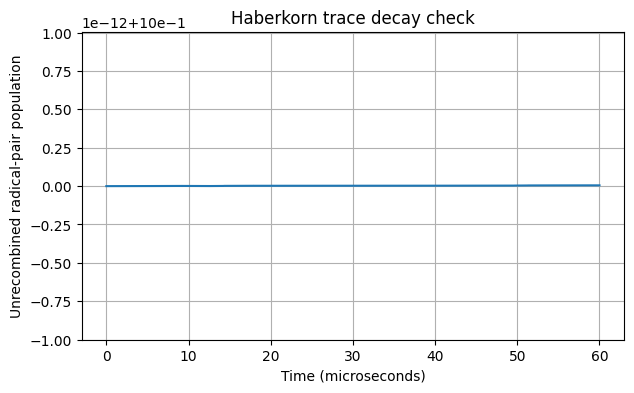

In [45]:
# ============================================================
# Haberkorn output diagnostic check
# Replace your duplicated check_haberkorn_output cell with this
# ============================================================

def check_haberkorn_output(out, tolerance=5e-3):
    """
    Checks whether the Haberkorn simulation is physically valid.
    Does not immediately crash; it prints diagnostics first.
    """
    Phi_S = out["Phi_S"]
    Phi_T = out["Phi_T"]
    final_trace = out["final_trace"]
    yield_check = out["yield_check"]
    trace_t = out["trace_t"]

    print("========== HABERKORN CHECK ==========")
    print("Phi_S:", Phi_S)
    print("Phi_T:", Phi_T)
    print("Final trace:", final_trace)
    print("Phi_S + Phi_T + final_trace:", yield_check)
    print("Initial trace:", trace_t[0])
    print("Final trace:", trace_t[-1])
    print("Minimum trace:", np.min(trace_t))
    print("Maximum trace:", np.max(trace_t))
    print("====================================")

    passed = True

    if not (-tolerance <= Phi_S <= 1.0 + tolerance):
        print("ERROR: Phi_S is outside [0, 1].")
        passed = False

    if not (-tolerance <= Phi_T <= 1.0 + tolerance):
        print("ERROR: Phi_T is outside [0, 1].")
        passed = False

    if abs(yield_check - 1.0) > tolerance:
        print("ERROR: Yield check is not close to 1.")
        print("Difference from 1:", yield_check - 1.0)
        passed = False

    if trace_t[-1] > 1e-3:
        print("WARNING: final trace is not tiny. Increase n_lifetimes or t_max.")

    if trace_t[-1] > trace_t[0]:
        print("ERROR: trace increased instead of decaying.")
        passed = False

    if passed:
        print("Haberkorn check passed.")

    return passed


single_test = simulate_haberkorn_for_theta(
    theta_deg=45,
    kS=2.0e5,
    kT=2.0e5,
    a_bar_time=1.0e-6,
    B_strength=B0,
    phi_deg=0.0,
    Gamma_iso=0.0,
    n_steps=4000,
    n_lifetimes=12
)

passed = check_haberkorn_output(single_test)

plt.figure(figsize=(7, 4))
plt.plot(single_test["tlist"] * 1e6, single_test["trace_t"])
plt.xlabel("Time (microseconds)")
plt.ylabel("Unrecombined radical-pair population")
plt.title("Haberkorn trace decay check")
plt.grid(True)
plt.show()

In [46]:
def singlet_yield_vs_theta(
    theta_values=None,
    kS=2.0e5,
    kT=None,
    a_bar_time=1.0e-6,
    B_strength=B0,
    phi_deg=0.0,
    Gamma_iso=0.0,
    n_steps=4000,
    n_lifetimes=12
):
    """
    Computes ΦS(theta) over a theta grid.
    """
    if theta_values is None:
        theta_values = np.linspace(0, 90, 19)

    theta_values = np.array(theta_values, dtype=float)

    Phi_S_values = []
    Phi_T_values = []
    final_traces = []
    yield_checks = []

    for theta in theta_values:
        out = simulate_haberkorn_for_theta(
            theta_deg=theta,
            kS=kS,
            kT=kT,
            a_bar_time=a_bar_time,
            B_strength=B_strength,
            phi_deg=phi_deg,
            Gamma_iso=Gamma_iso,
            n_steps=n_steps,
            n_lifetimes=n_lifetimes
        )

        Phi_S_values.append(out["Phi_S"])
        Phi_T_values.append(out["Phi_T"])
        final_traces.append(out["final_trace"])
        yield_checks.append(out["yield_check"])

    Phi_S_values = np.array(Phi_S_values)
    Phi_T_values = np.array(Phi_T_values)
    final_traces = np.array(final_traces)
    yield_checks = np.array(yield_checks)

    DeltaPhi = Phi_S_values.max() - Phi_S_values.min()

    return {
        "theta_values": theta_values,
        "Phi_S_values": Phi_S_values,
        "Phi_T_values": Phi_T_values,
        "final_traces": final_traces,
        "yield_checks": yield_checks,
        "DeltaPhi": DeltaPhi,
        "Phi_S_max": Phi_S_values.max(),
        "Phi_S_min": Phi_S_values.min()
    }

In [47]:
theta_values = np.linspace(0, 90, 19)

curve_47 = singlet_yield_vs_theta(
    theta_values=theta_values,
    kS=2.0e5,
    kT=2.0e5,
    a_bar_time=1.0e-6,
    B_strength=B0,
    phi_deg=0.0,
    Gamma_iso=0.0,
    n_steps=4000,
    n_lifetimes=12
)

print("\n47 µT curve:")
print("Phi_S max:", curve_47["Phi_S_max"])
print("Phi_S min:", curve_47["Phi_S_min"])
print("Delta Phi:", curve_47["DeltaPhi"])
print("Mean final trace:", np.mean(curve_47["final_traces"]))
print("Mean yield check:", np.mean(curve_47["yield_checks"]))

if np.any(curve_47["Phi_S_values"] > 1.0):
    raise RuntimeError("ERROR: singlet yield exceeded 1. Something is wrong.")

plt.figure(figsize=(8, 5))
plt.plot(curve_47["theta_values"], curve_47["Phi_S_values"], marker="o", label="47 µT")
plt.xlabel("Inclination angle θ (degrees)")
plt.ylabel("Singlet product yield ΦS")
plt.title("Haberkorn singlet yield vs inclination angle")
plt.grid(True)
plt.legend()
plt.show()


47 µT curve:
Phi_S max: 5.897523701368208
Phi_S min: 5.615051520194662
Delta Phi: 0.2824721811735458
Mean final trace: 0.9999999999999997
Mean yield check: 12.999999999999995


RuntimeError: ERROR: singlet yield exceeded 1. Something is wrong.

In [ ]:
curve_weak = singlet_yield_vs_theta(
    theta_values=theta_values,
    kS=2.0e5,
    kT=2.0e5,
    a_bar_time=1.0e-6,
    B_strength=0.7 * B0,
    phi_deg=0.0,
    Gamma_iso=0.0,
    n_steps=4000,
    n_lifetimes=12
)

print("\n30% weaker field curve:")
print("Phi_S max:", curve_weak["Phi_S_max"])
print("Phi_S min:", curve_weak["Phi_S_min"])
print("Delta Phi:", curve_weak["DeltaPhi"])
print("Mean yield check:", np.mean(curve_weak["yield_checks"]))

plt.figure(figsize=(8, 5))
plt.plot(curve_47["theta_values"], curve_47["Phi_S_values"], marker="o", label="47 µT")
plt.plot(curve_weak["theta_values"], curve_weak["Phi_S_values"], marker="s", label="30% weaker field")
plt.xlabel("Inclination angle θ (degrees)")
plt.ylabel("Singlet product yield ΦS")
plt.title("Singlet yield: local geomagnetic field vs 30% weaker field")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
Gamma_values = np.array([0.0, 1e3, 1e4, 1e5, 4e5, 1e6, 1e7])

DeltaPhi_values = []

for Gamma in Gamma_values:
    curve_noise = singlet_yield_vs_theta(
        theta_values=theta_values,
        kS=2.0e5,
        kT=2.0e5,
        a_bar_time=1.0e-6,
        B_strength=B0,
        phi_deg=0.0,
        Gamma_iso=Gamma,
        n_steps=3000,
        n_lifetimes=12
    )

    DeltaPhi_values.append(curve_noise["DeltaPhi"])

DeltaPhi_values = np.array(DeltaPhi_values)

plt.figure(figsize=(8, 5))
plt.semilogx(Gamma_values + 1, DeltaPhi_values, marker="o")
plt.xlabel("Environmental noise rate Γ (s⁻¹)")
plt.ylabel("Compass sensitivity ΔΦ")
plt.title("Compass sensitivity vs isotropic decoherence rate")
plt.grid(True)
plt.show()

print("\nDecoherence sweep:")
for Gamma, DeltaPhi in zip(Gamma_values, DeltaPhi_values):